In [172]:
import pandas as pd
import numpy as np

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [173]:
# Load dataset
df = pd.read_csv("pest_disease_management_dataset.csv")

In [174]:
# Check data
print(df.head())
print(df.info())

   record_id        date  season         region  latitude  longitude  \
0  REC000001  2020-05-10    Zaid     Tamil_Nadu   15.0977    70.0287   
1  REC000002  2021-07-18    Rabi  Uttar_Pradesh   20.7853    86.7055   
2  REC000003  2021-02-04    Rabi        Haryana   13.0935    71.4111   
3  REC000004  2020-12-31  Kharif        Haryana   16.7936    81.9974   
4  REC000005  2022-06-27    Rabi        Gujarat   11.4744    71.4889   

   crop_type previous_crop growth_stage  crop_age_days  ...  \
0     Tomato         Maize   Vegetative             27  ...   
1      Wheat          Rice     Maturity            140  ...   
2     Cotton        Cotton   Vegetative            152  ...   
3      Maize     Groundnut   Harvesting             35  ...   
4  Groundnut        Tomato     Seedling             56  ...   

   crop_price_INR_per_ton treatment_cost_INR_per_ha  economic_loss_INR_per_ha  \
0                 39921.0                    1415.0                    9383.0   
1                 10631.0 

In [175]:
data = df.copy()

# Drop irrelevant columns
drop_cols = ['record_id', 'date']
data = data.drop(columns=drop_cols, errors='ignore')


In [176]:
# Encode categorical columns
for col in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

In [177]:
target_col = 'intervention_flag' 

X = data.drop(target_col, axis=1)
y = data[target_col]

In [178]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [179]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [180]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

In [181]:
model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [182]:
y_pred = model.predict(X_test)

In [183]:
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"\nAccuracy: {accuracy:.2f}%")


Accuracy: 100.00%


In [184]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6268
           1       1.00      1.00      1.00     12132

    accuracy                           1.00     18400
   macro avg       1.00      1.00      1.00     18400
weighted avg       1.00      1.00      1.00     18400



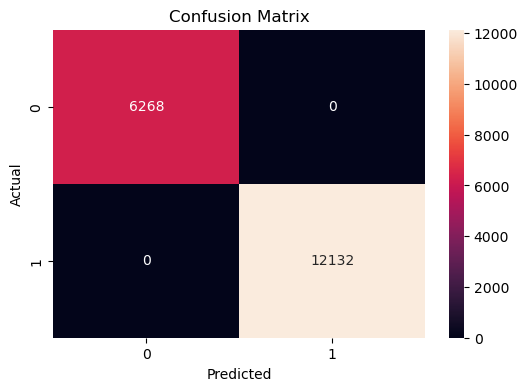

In [185]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Model, Scaler, Encoders saved successfully!

Sample Prediction: 1


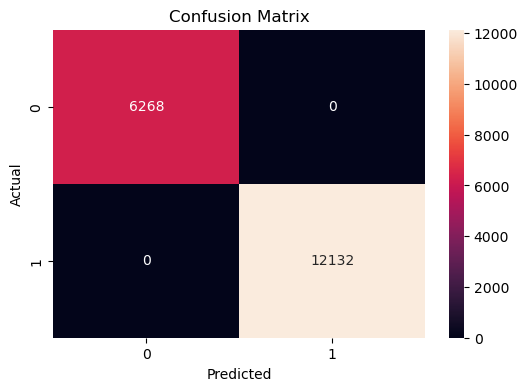

In [186]:
# ================= SAVE MODEL =================
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoders, "encoders.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

print("\nModel, Scaler, Encoders saved successfully!")

# ================= SAMPLE PREDICTION =================
sample = X.iloc[0:1]

sample_scaled = scaler.transform(sample)
pred = model.predict(sample_scaled)

print("\nSample Prediction:", pred[0])

# ================= CONFUSION MATRIX =================
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()